# Analysis Notebook - Phần 3

Báo cáo thực nghiệm cho Phần 3: so sánh tốc độ, residual, và tính ổn định của các phương pháp giải Ax = b.

Các thuật toán đã đồng bộ với Part 1 và Part 2:
- Gauss lấy từ Part 1 (`gaussian_eliminate`)
- Cholesky từ Part 2
- Phương pháp lặp Gauss-Seidel

Mục tiêu:
- Kiểm tra nhanh độ đúng của solver
- Benchmark với n = [50, 100, 200, 500, 1000]
- Vẽ đồ thị log-log và so sánh với O(n^3)
- Phân tích condition number và độ ổn định: Hilbert vs SPD

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt

MODULES_READY = False

try:
    from solvers import (
        gaussian_solve_part1,
        solve_cholesky,
        gauss_seidel,
        relative_residual,
    )
    from benchmark import (
        benchmark_sizes,
        plot_runtime_loglog,
        print_result_table,
        stability_case_study,
        print_stability_report,
    )
    MODULES_READY = True
except Exception as exc:
    print(f"Chưa nạp được module lõi: {exc}")

plt.rcParams['figure.figsize'] = (9, 6)

### 1. Kiểm tra nhanh độ đúng

Dùng bộ dữ liệu SPD ở Phần 2 để đối chiếu liền mạch giữa Cholesky (Part 2) và các solver trong Part 3.

In [ ]:
A = [
    [4.0, 4.0, 2.0],
    [4.0, 8.0, 6.0],
    [2.0, 6.0, 9.0],
]
b = [14.0, 26.0, 23.0]

# Tránh lỗi NameError nếu chạy cell này trước cell import.
if 'MODULES_READY' not in globals():
    MODULES_READY = False

if MODULES_READY:
    x_gauss, info_gauss = gaussian_solve_part1(A, b)
    x_chol, info_chol = solve_cholesky(A, b)
    x_gs, info_gs = gauss_seidel(A, b, tol=1e-10, max_iter=10000)

    print('Gauss (Part 1):', x_gauss, info_gauss, 'residual=', relative_residual(A, x_gauss, b))
    print('Cholesky      :', x_chol, info_chol, 'residual=', relative_residual(A, x_chol, b))
    print('Gauss-Seidel  :', x_gs, info_gs, 'residual=', relative_residual(A, x_gs, b))
else:
    print('Hãy chạy cell import trước để nạp module.')

Gauss (Part 1): [1.0, 2.0, 1.0] {'swaps': 0, 'source': 'part1.gaussian_eliminate'} residual= 0.0
Cholesky      : [1.0, 2.0, 1.0] {'factorization': 'cholesky'} residual= 0.0
Gauss-Seidel  : [1.000000000227538, 1.9999999997957467, 1.0000000000856049] {'iterations': 57, 'converged': True, 'diag_dominant': False} residual= 9.023862043074613e-12


## 2. Benchmark chính

Chạy benchmark với 5 kích thước và 5 lần lặp cho mỗi kích thước.

In [ ]:
if MODULES_READY:
    sizes = [50, 100, 200, 500, 1000]
    results = benchmark_sizes(sizes=sizes, repeats=5)
    print_result_table(results, sizes)
else:
    print('Benchmark sẽ chạy sau khi hoàn thiện benchmark.py.')

[n=  50] gauss_part1  | thoi_gian_tb=0.004922s | residual_tb=3.655e-16
[n=  50] cholesky     | thoi_gian_tb=0.002252s | residual_tb=1.628e-16
[n=  50] gauss_seidel | thoi_gian_tb=0.001750s | residual_tb=1.353e-08
[n= 100] gauss_part1  | thoi_gian_tb=0.033926s | residual_tb=5.706e-16
[n= 100] cholesky     | thoi_gian_tb=0.014820s | residual_tb=1.692e-16
[n= 100] gauss_seidel | thoi_gian_tb=0.006433s | residual_tb=2.303e-08
[n= 200] gauss_part1  | thoi_gian_tb=0.255128s | residual_tb=8.417e-16
[n= 200] cholesky     | thoi_gian_tb=0.109301s | residual_tb=1.785e-16
[n= 200] gauss_seidel | thoi_gian_tb=0.023529s | residual_tb=2.888e-08
[n= 500] gauss_part1  | thoi_gian_tb=4.120615s | residual_tb=1.143e-15
[n= 500] cholesky     | thoi_gian_tb=1.784314s | residual_tb=1.576e-16
[n= 500] gauss_seidel | thoi_gian_tb=0.131831s | residual_tb=1.401e-07
[n=1000] gauss_part1  | thoi_gian_tb=34.687470s | residual_tb=1.500e-15
[n=1000] cholesky     | thoi_gian_tb=16.136813s | residual_tb=1.702e-16
[n=1

## 3. Đồ thị log-log

Vẽ runtime theo kích thước ma trận và thêm đường tham chiếu O(n^3).

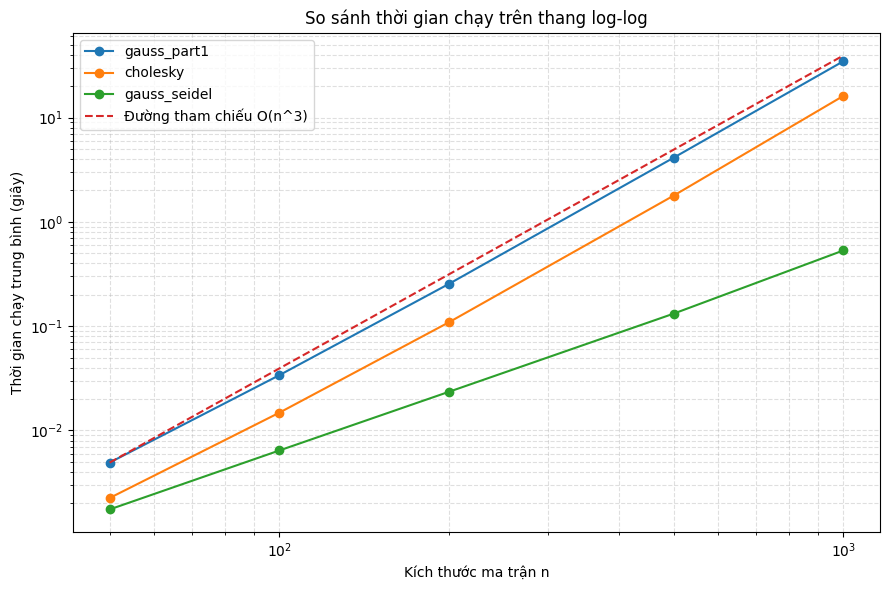

In [ ]:
if MODULES_READY:
    plot_runtime_loglog(results, sizes)
else:
    print('Vẽ đồ thị sau khi benchmark xong.')

### 4. Phân tích ổn định số học

Dựa theo lý thuyết số điều kiện κ(A), ta sẽ chạy case study Hilbert và SPD, rồi in báo cáo condition number + residual của từng phương pháp.

In [ ]:
if MODULES_READY:
    report = stability_case_study(ns=[5, 8, 10], seed=42)
    print_stability_report(report)
else:
    print('Chạy phân tích ổn định sau khi nạp module thành công.')


===== ỔN ĐỊNH SỐ: HILBERT VS SPD =====

[HILBERT]
n= 5 | cond2=4.766e+05 | res_gauss=1.593e-14 | res_cholesky=1.468e-14 | res_gs=1.135e-03 | gs_hoi_tu=0
n= 8 | cond2=1.526e+10 | res_gauss=2.115e-12 | res_cholesky=2.591e-12 | res_gs=1.271e-03 | gs_hoi_tu=0
n=10 | cond2=1.602e+13 | res_gauss=9.521e-11 | res_cholesky=6.013e-11 | res_gs=1.063e-03 | gs_hoi_tu=0

[SPD]
n= 5 | cond2=1.825e+00 | res_gauss=7.022e-17 | res_cholesky=1.790e-16 | res_gs=1.981e-10 | gs_hoi_tu=1
n= 8 | cond2=2.056e+00 | res_gauss=9.615e-17 | res_cholesky=1.799e-16 | res_gs=1.913e-09 | gs_hoi_tu=1
n=10 | cond2=2.204e+00 | res_gauss=1.490e-16 | res_cholesky=1.110e-16 | res_gs=1.093e-09 | gs_hoi_tu=1


### 5. Kết luận

- **Tính chính xác:** Trên các bài test SPD, cả ba phương pháp đều cho nghiệm nhất quán; Gauss và Cholesky đạt residual rất nhỏ, còn Gauss-Seidel cho sai số lớn hơn một chút nhưng vẫn đạt độ chính xác tốt khi hội tụ.
- **So sánh phương pháp:** Trên bộ benchmark SPD hiện tại, Gauss-Seidel thường nhanh nhất nhờ số vòng lặp nhỏ; trong hai phương pháp trực tiếp, Cholesky thường nhanh hơn Gauss và vẫn giữ độ chính xác cao.
- **Tính ổn định:** Khi ma trận có điều kiện tốt (SPD ngẫu nhiên, condition number nhỏ), cả ba phương pháp hoạt động ổn định. Với ma trận điều kiện xấu (Hilbert), residual của phương pháp trực tiếp tăng lên và Gauss-Seidel có thể không hội tụ trong giới hạn lặp đặt trước.
- **Kết luận:** Ma trận SPD, Cholesky là lựa chọn trực tiếp rất tốt về cả tốc độ và độ ổn định. Gauss-Seidel phù hợp khi cần nghiệm gần đúng nhanh và bài toán thỏa điều kiện hội tụ. Với ma trận kém điều kiện, nên ưu tiên phương pháp trực tiếp/ổn định hơn và kiểm tra residual sau khi giải.